In [31]:
#imports from the OPENCV Website 3d training brain tumor segmentaiton. We created a model from scratch, and altered the data preprocessing and data loading code to work for our
#segment anything model + 3d unet + 2d decoder fusion, while utilizing some of their pre-built data loading methods. 

#DATASET:
#https://www.kaggle.com/datasets/aiocta/brats2023-part-1

GPU_AVAILABLE = False
from torch.utils.tensorboard import SummaryWriter
!pip install nibabel -q
!pip install scikit-learn -q
!pip install tqdm -q
!pip install split-folders -q
!pip install torchinfo -q
!pip install segmentation-models-pytorch-3d -q
!pip install livelossplot -q
!pip install torchmetrics -q
!pip install tensorboard -q
import os
import random
import splitfolders
from tqdm import tqdm
import nibabel as nib
import glob
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import shutil
import time
 
from dataclasses import dataclass
 
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR
import torchvision.transforms as transforms
from torch.cuda import amp
 
from torchmetrics import MeanMetric
from torchmetrics.classification import MulticlassAccuracy
 
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
from torchinfo import summary
import gc
 
import segmentation_models_pytorch_3d as smp
 
from livelossplot import PlotLosses
from livelossplot.outputs import MatplotlibPlot, ExtremaPrinter
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [260]:


!cp ~/kaggle.json ~/.kaggle
! chmod 600 /Users/adamessawi/.kaggle/kaggle.json


In [41]:




from segment_anything import SamPredictor, sam_model_registry



# This comes from the 'Getting Started' sample code provided on the repo page
checkpoint_path = Path.home() / "Downloads" / "sam_vit_b_01ec64.pth"
sam = sam_model_registry["vit_b"](checkpoint_path)
predictor = SamPredictor(sam)

# *** This is how you can access the patch embeddings ***
patch_embeddings = predictor.features





In [3]:
train_loader = DataLoader(train_dataset, batch_size = 5, shuffle = True, num_workers = 0)
val_loader = DataLoader(val_dataset, batch_size = 5, shuffle = False, num_workers = 0)

NameError: name 'train_dataset' is not defined

In [4]:
import os
#may need to change to fit own environment
DATASET_PATH = "BraTS2023-Glioma"
print("Total Files: ", len(os.listdir(DATASET_PATH)))

Total Files:  625


In [5]:
import glob
t1ce_list = sorted(glob.glob(f"{DATASET_PATH}/*/*t1c.nii"))
t2_list = sorted(glob.glob(f"{DATASET_PATH}/*/*t2w.nii"))
flair_list = sorted(glob.glob(f"{DATASET_PATH}/*/*t2f.nii"))
mask_list = sorted(glob.glob(f"{DATASET_PATH}/*/*seg.nii"))
print("t1ce list: ", len(t1ce_list))
print("t2 list: ", len(t2_list))
print("flair list: ", len(flair_list))
print("Mask list: ", len(mask_list))

t1ce list:  625
t2 list:  625
flair list:  625
Mask list:  625


In [113]:
#This is OPENCV - Brain Tumour Segmentation Scaling method, we extend to our SAM encoder.
#!pip install nibabel
from sklearn.preprocessing import MinMaxScaler
import nibabel as nib
import numpy as np
scaler = MinMaxScaler()

i = 0
#load the image into a numpy array
for i in range(len(t2_list)):
    temp_image_t1ce = nib.load(t1ce_list[i]).get_fdata()
    #flatten the array and apply scaling to values between 0 and 1
    flatten_img = temp_image_t1ce.reshape(-1, 1)
    scaled_img = scaler.fit_transform(flatten_img)
    temp_image_t1ce = scaled_img.reshape(temp_image_t1ce.shape)
    #do this process for all 3 reshapeable values. 
    
    temp_image_t2 = nib.load(t2_list[i]).get_fdata()
    #flatten the array and apply scaling to values between 0 and 1
    flatten_img = temp_image_t1ce.reshape(-1, 1)
    scaled_img = scaler.fit_transform(flatten_img)
    temp_image_t2 = scaled_img.reshape(temp_image_t1ce.shape)

    temp_image_flair = nib.load(flair_list[i]).get_fdata()
    #flatten the array and apply scaling to values between 0 and 1
    flatten_img = temp_image_t1ce.reshape(-1, 1)
    scaled_img = scaler.fit_transform(flatten_img)
    temp_image_flair = scaled_img.reshape(temp_image_t1ce.shape)

    temp_image_mask = nib.load(mask_list[i]).get_fdata()

    temp_combine_image = np.stack([temp_image_t1ce, temp_image_flair, temp_image_t2], axis=3)

    temp_2d_combine_image = temp_combine_image[56:184, 56:184, 77:78]
    temp_image_mask = temp_image_mask[56:184, 56:184, 77:78]
    temp_combine_image = temp_combine_image[56:184, 56:184, 62:92]
    
    
    temp_2d_combine_image = temp_2d_combine_image.squeeze()
    predictor.set_image(temp_2d_combine_image)
    
    
    
    val, counts = np.unique(temp_image_mask, return_counts=True)
  
    print(i)
    i = i + 1
    if (1 - (counts[0] / counts.sum())) > 0.01:

        temp_image_mask = F.one_hot(torch.tensor(temp_image_mask, dtype=torch.long), num_classes=4)
        os.makedirs("BraTS2023_Preprocessed/input_data_3channels/images2D", exist_ok=True)
        os.makedirs("BraTS2023_Preprocessed/input_data_3channels/images3D", exist_ok=True)
        os.makedirs("BraTS2023_Preprocessed/input_data_3channels/masks", exist_ok=True)
        np.save(
            "BraTS2023_Preprocessed/input_data_3channels/images3D/image_"
            + str(i)
            + ".npy",
            temp_combine_image,
        )
        np.save(
            "BraTS2023_Preprocessed/input_data_3channels/masks/mask_"
            + str(i)
            + ".npy",
            temp_image_mask,
        )
        np.save(
            "BraTS2023_Preprocessed/input_data_3channels/images2D/image_"
            + str(i)
            + ".npy",
            predictor.features.cpu().numpy(),
        )
        
    else:
        pass
    
    
        
        
        
    
 

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

In [193]:
#Neural Net Helper Functions

import torch
import torch.nn as nn



#2D Double convolution Layer:
def Dimreduction(nn_input, nn_output):
    return nn.Sequential(
    nn.Conv2d(nn_input, nn_output, kernel_size=3, padding=1),
    nn.BatchNorm2d(nn_output),
    nn.ReLU(inplace=True),
    nn.Conv2d(nn_output, nn_output, kernel_size=3, padding=1),
    nn.BatchNorm2d(nn_output),
    nn.ReLU(inplace=True)
    )

#3D Double Convolution Layer:
def Doubleconv(nn_input, nn_output):
    return nn.Sequential(
    nn.Conv3d(nn_input, nn_output, kernel_size=3, padding=1),
    nn.BatchNorm3d(nn_output),
    nn.ReLU(inplace=True),
    nn.Dropout(0.1 if nn_output <= 32 else 0.2 if nn_output <= 128 else 0.3),
    nn.Conv3d(nn_output, nn_output, kernel_size=3, padding=1),
    nn.BatchNorm3d(nn_output),
    nn.ReLU(inplace=True)
    )

    
class Fusionnet(nn.Module):
    def __init__(self, channel_in, channel_out):
        super().__init__()
        self.decode1 = Dimreduction(256, 128)
        self.decode2 = Dimreduction(128, 64)
        self.decode3 = Dimreduction(64, 32)
        self.decode4 = Dimreduction(32, 16)
        self.Metaconv1 = Dimreduction(256, 192)
        self.Metapool1 = nn.MaxPool2d(kernel_size=2)
        self.Metaconv2 = Dimreduction(192, 128)
        self.Metapool2 = nn.MaxPool2d(kernel_size=2)
        self.Metaconv3 = Dimreduction(3, 128)
        self.Metaconv5 = Dimreduction(7, 64)
        self.Metaconv6 = Dimreduction(15, 32)
        self.Metaconv7 = Dimreduction(30, 16)
        self.Metaconv4 = Dimreduction(128, 256)
        self.Metapool3 = nn.MaxPool2d(kernel_size=2)
        self.threedconv1 = Doubleconv(3, 16)
        self.threedpool1 = nn.MaxPool3d(kernel_size=2)
        self.threedconv2 = Doubleconv(16, 32)
        self.threedpool2 = nn.MaxPool3d(kernel_size=2)
        self.threedconv3 = Doubleconv(32, 64)
        self.threedpool3 = nn.MaxPool3d(kernel_size=2)
        self.threedconv4 = Doubleconv(64, 128)
        self.flattenthreed = nn.Conv3d(128, 1, kernel_size=1)
        self.flattenthreed1 = nn.Conv3d(64, 1, kernel_size=1)
        self.flattenthreed2 = nn.Conv3d(32, 1, kernel_size=1)
        self.flattenthreed3 = nn.Conv3d(16, 1, kernel_size=1)
        self.finalconv = nn.Conv2d(16, channel_out, kernel_size=1)
        self.attn = nn.MultiheadAttention(embed_dim=128, num_heads=8)
        self.upconv6 = nn.ConvTranspose2d(in_channels=256, out_channels=128, kernel_size=2, stride=2)
        self.conv6 = (256, 128)
        self.upconv7 = nn.ConvTranspose2d(in_channels=128, out_channels=64, kernel_size=2, stride=2)
        self.conv7 = Doubleconv(128, 64)
        self.upconv8 = nn.ConvTranspose2d(in_channels=64, out_channels=32, kernel_size=2, stride=2)
        self.conv8 = Doubleconv(64, 32)
        self.upconv9 = nn.ConvTranspose2d(in_channels=32, out_channels=16, kernel_size=2, stride=2)
        self.conv9 = Doubleconv(32, 16)
        self.out_conv = nn.Conv2d(in_channels=16, out_channels=channel_out, kernel_size=1)

#Forward Function for our model.
#y = sam input, x = 3d encode input
    def forward(self, x, y):
        var11 = self.Metaconv1(y)
        var22 = self.Metapool1(var11)
        var33 = self.Metaconv2(var22)
        var44 = self.Metapool2(var33)
        var1 = self.threedconv1(x)
        var2 = self.threedpool1(var1)
        var3 = self.threedconv2(var2)
        var4 = self.threedpool2(var3)
        var5 = self.threedconv3(var4)
        var6 = self.threedpool3(var5)
        var7 = self.threedconv4(var6)
        var8 = self.flattenthreed(var7)
        var9 = var8.squeeze(1)
        var10 = self.Metaconv3(var9)

        #fusion methods

        #Multihead Attention Block:
         #var10_flat = var10.view(B, C, -1).permute(2, 0, 1)
         #var44_flat = var44.view(B, C, -1).permute(2, 0, 1)
         #attn_output, attn_weights = self.attn(query=var10_flat, key=var44_flat, value=var44_flat)
         #attn_output = attn_output.permute(1, 2, 0).view(B, C, H, W)
         #var11 = attn_output + var10

        #Convolution Fusion:
        #C = torch.cat([var10, var44], dim=1)
        #var11 = self.decode1(C)

        #Additive Fusion:
        #var11 = var10 + var44
        var12 = self.Metaconv4(var11)
        var13 = self.Metapool3(var12)


        #Decoder start
        var14 = self.upconv6(var13)
        var15 = torch.cat([var14, var10], dim=1)
        var16 = self.decode1(var15)
        var17 = self.upconv7(var16)
        var18 = self.flattenthreed1(var5)
        var19 = var18.squeeze(1)
        var20 = self.Metaconv5(var19)
        var21 = torch.cat([var17, var20], dim=1)
        var22 = self.decode2(var21)
        var23 = self.upconv8(var22)
        var24 = self.flattenthreed2(var3)
        var25 = var24.squeeze(1)
        var26 = self.Metaconv6(var25)
        var27 = torch.cat([var23, var26], dim=1)
        var28 = self.decode3(var27)
        var29 = self.upconv9(var28)
        var30 = self.flattenthreed3(var1)
        var31 = var30.squeeze(1)
        var32 = self.Metaconv7(var31)
        var33 = torch.cat([var29, var32], dim=1)
        var34 = self.decode4(var33)
        outputs = self.finalconv(var34)
        return outputs





In [11]:
#Neural net class

images_folder = "BraTS2023_Preprocessed/input_data_3channels/images2D"
print(len(os.listdir(images_folder)))

images_folder = "BraTS2023_Preprocessed/input_data_3channels/images3D"
print(len(os.listdir(images_folder)))
 
masks_folder = "BraTS2023_Preprocessed/input_data_3channels/masks"
print(len(os.listdir(masks_folder)))

516
516
516


In [194]:

#Already predefined dataloader written through opencv - altered for our particular use case:
from torch.utils.data import Dataset
class BratsDataset(Dataset):
    def __init__(self, img_dir_3d, img_dir_2d, mask_dir, normalization=True):
        super().__init__()
        
        self.img_dir_3d = img_dir_3d
        self.img_dir_2d = img_dir_2d
        self.mask_dir = mask_dir
        self.img_list_3d = sorted(
            os.listdir(img_dir_3d)
        )  # Ensure sorting to match images and masks
        self.img_list_2d = sorted(
            os.listdir(img_dir_2d)
        )
        
        self.mask_list = sorted(os.listdir(mask_dir))
        self.normalization = normalization
 
        # If normalization is True, set up a normalization transform
        if self.normalization:
            self.normalizer = transforms.Normalize(
                mean=[0.5], std=[0.5]
            )  # Adjust mean and std based on your data

    
    def load_file(self, filepath):
        return np.load(filepath)
 
    def __len__(self):
        return len(self.img_list_2d)

    def __getitem__(self, idx): 
        
        image_path_3d = os.path.join(self.img_dir_3d, self.img_list_3d[idx])
        image_path_2d = os.path.join(self.img_dir_2d, self.img_list_2d[idx])
        mask_path = os.path.join(self.mask_dir, self.mask_list[idx])
        
       # Load the image and mask
        image_3d = self.load_file(image_path_3d)
        image_2d = self.load_file(image_path_2d)
        mask = self.load_file(mask_path)
 
       # Convert to torch tensors and permute axes to C, D, H, W format (needed for 3D models)
        
        image_3d = torch.from_numpy(image_3d).permute(3, 2, 0, 1).float()  # Shape: C, D, H, W
   
        
       

        image_2d = image_2d.squeeze()
       
        image_2d = torch.from_numpy(image_2d).float()
    
        
    
        mask = mask.squeeze()
        mask = torch.from_numpy(mask).permute(2, 0, 1) 
 
        
       # Normalize the image if normalization is enabled
        if self.normalization:
            image_3d = self.normalizer(image_3d)
            image_2d = self.normalizer(image_2d)
        
        return image_3d, image_2d, mask
   
    



In [28]:
input_folder = "BraTS2023_Preprocessed/input_data_3channels/"

output_folder = "BraTS2023_Preprocessed/input_data_128/"
 
splitfolders.ratio(
    input_folder, output_folder, seed=42, ratio=(0.7, 0.15, 0.15), group_prefix=None
)


Copying files: 0 files [00:00, ? files/s]
Copying files: 20 files [00:00, 198.72 files/s]
Copying files: 42 files [00:00, 209.36 files/s]
Copying files: 64 files [00:00, 213.32 files/s]
Copying files: 87 files [00:00, 219.03 files/s]
Copying files: 112 files [00:00, 227.41 files/s]
Copying files: 135 files [00:00, 225.16 files/s]
Copying files: 158 files [00:00, 224.89 files/s]
Copying files: 181 files [00:00, 222.40 files/s]
Copying files: 204 files [00:00, 224.09 files/s]
Copying files: 227 files [00:01, 224.84 files/s]
Copying files: 250 files [00:01, 225.97 files/s]
Copying files: 273 files [00:01, 225.51 files/s]
Copying files: 297 files [00:01, 228.05 files/s]
Copying files: 322 files [00:01, 233.15 files/s]
Copying files: 346 files [00:01, 233.27 files/s]
Copying files: 370 files [00:01, 235.17 files/s]
Copying files: 394 files [00:01, 234.67 files/s]
Copying files: 418 files [00:01, 235.81 files/s]
Copying files: 442 files [00:01, 236.13 files/s]
Copying files: 466 files [00:0

In [ ]:
!pip install split-folders
import splitfolders

Copying files: 244 files [00:20, 161.24 files/s]

In [195]:

model = Fusionnet(channel_in=3, channel_out=4)



 









In [196]:
#defining loss:
dice_loss = smp.losses.DiceLoss(
   mode="multiclass",          
   classes=None,               
   log_loss=False,            
   from_logits=True,         
   smooth=1e-5,                
   ignore_index=None,      
   eps=1e-7                   
)
 
focal_loss = smp.losses.FocalLoss(
   mode="multiclass",        
   alpha=0.25,              
   gamma=2.0                   
)
 
def combined_loss(output, target):
   loss1 = dice_loss(output, target)
   loss2 = focal_loss(output, target)
   
    
   return loss1 + loss2
    

In [197]:
def create_checkpoint_dir(checkpoint_dir):
    if not os.path.exists(checkpoint_dir):
        os.makedirs(checkpoint_dir)
    try:
        num_versions = [
            int(i.split("_")[-1]) for i in os.listdir(checkpoint_dir) if "version" in i
        ]
        version_num = max(num_versions) + 1
 
    except:
        version_num = 0
 
    version_dir = os.path.join(checkpoint_dir, "version_" + str(version_num))
    os.makedirs(version_dir)
 
    print(f"Checkpoint directory: {version_dir}")
    return version_dir

In [198]:
seed_everything(SEED = 42)
  
CKPT_DIR = create_checkpoint_dir(TrainingConfig.CHECKPOINT_DIR)
 
from torch.optim import AdamW
 
optimizer = AdamW(
   model.parameters(),
   lr=TrainingConfig.LEARNING_RATE, 
   weight_decay=1e-2,                # Regularization to avoid overfitting
   amsgrad=True                      # Optional AMSGrad variant
)

Checkpoint directory: model_checkpoint/3D_UNet_Brats2023/version_49


In [199]:
def train_one_epoch(
   model,
   loader,
   optimizer,
   num_classes,
   device="cpu",
   epoch_idx=800,
   total_epochs=50):
 
   model.train()
 
 
   loss_record = MeanMetric()
   metric_record = MeanMetric()
   acc_record = MulticlassAccuracy(num_classes=num_classes, average='macro')  # Use macro-average accuracy
 
   loader_len = len(loader)
 
   with tqdm(total=loader_len, ncols=122) as tq:
       tq.set_description(f"Train ::  Epoch: {epoch_idx}/{total_epochs}")
 
       for image_3d, image_2d, target in loader:
           tq.update(1)
           

           image_3d = image_3d.to(device)
           image_2d = image_2d.to(device)
           target = target.to(device)
           
           optimizer.zero_grad()

           output_dict = model(image_3d, image_2d)
           
           
           target = target.argmax(dim=1)  # Convert one-hot to class indices
 
           clsfy_out = output_dict  # classifier head output
 
           loss = combined_loss(clsfy_out, target)
 
           # Calculate gradients w.r.t training parameters
           loss.backward()
           optimizer.step()
 
           # Detach for evaluation
           with torch.no_grad():
            
               pred_idx = clsfy_out.argmax(dim=1)
 
               # Calculate stats and IoU
               tp, fp, fn, tn = smp.metrics.get_stats(pred_idx, target, mode='multiclass', num_classes=num_classes)
               
               # Macro IoU and class-wise IoU
               metric_macro = smp.metrics.iou_score(tp, fp, fn, tn, reduction='macro')
 
               acc_record.update(pred_idx.cpu(), target.cpu())
               loss_record.update(loss.detach().cpu(), weight=image_3d.shape[0])
               metric_record.update(metric_macro.cpu(), weight=image_3d.shape[0])
 
           tq.set_postfix_str(s=f"Loss: {loss_record.compute():.4f}, IoU: {metric_record.compute():.4f}, Acc: {acc_record.compute():.4f}")
 
   epoch_loss = loss_record.compute()
   epoch_metric = metric_record.compute()
   epoch_acc = acc_record.compute()
 
   return epoch_loss, epoch_metric, epoch_acc

In [200]:
def seed_everything(SEED):
   np.random.seed(SEED)
   torch.manual_seed(SEED)
   torch.cuda.manual_seed_all(SEED)
   torch.backends.cudnn.deterministic = True
   torch.backends.cudnn.benchmark = False
 
 
def get_default_device():
   gpu_available = torch.cuda.is_available()
   return torch.device('cuda' if gpu_available else 'cpu'), gpu_available


In [201]:
from dataclasses import dataclass
@dataclass(frozen=True)
class TrainingConfig:
   BATCH_SIZE:      int = 5
   EPOCHS:          int = 60
   LEARNING_RATE: float = 1e-3
   CHECKPOINT_DIR:  str = os.path.join('model_checkpoint', '3D_UNet_Brats2023')
   NUM_WORKERS:     int = 0

In [ ]:
def validate(
   model,
   loader,
   device,
   num_classes,
   epoch_idx,
   total_epochs
):
   model.eval()
 
 
   loss_record = MeanMetric()
   metric_record = MeanMetric()
   acc_record = MulticlassAccuracy(num_classes=num_classes, average='macro')
 
   loader_len = len(loader)
 
   with tqdm(total=loader_len, ncols=122) as tq:
       tq.set_description(f"Valid :: Epoch: {epoch_idx}/{total_epochs}")
 
       for image_3d, image_2d, target in loader:
           tq.update(1)
 
           image_3d = image_3d.to(device)
           image_2d = image_2d.to(device)
           target = target.to(device)

           with torch.no_grad():
               output_dict = model(image_3d, image_2d)
               
           clsfy_out = output_dict
           target = target.argmax(dim=1)  # Convert one-hot to class indices
 
           loss = combined_loss(clsfy_out, target)
           pred_idx = clsfy_out.argmax(dim=1)
 
           tp, fp, fn, tn = smp.metrics.get_stats(pred_idx, target, mode='multiclass', num_classes=num_classes)
           
           # Macro IoU
           metric_macro = smp.metrics.iou_score(tp, fp, fn, tn, reduction='macro')
 
           acc_record.update(pred_idx.cpu(), target.cpu())
           loss_record.update(loss.cpu(), weight=image_3d.shape[0])
           metric_record.update(metric_macro.cpu(), weight=image_3d.shape[0]) #data.shape = batch
 
       valid_epoch_loss = loss_record.compute()
       valid_epoch_metric = metric_record.compute()
       valid_epoch_acc = acc_record.compute()
 
   return valid_epoch_loss, valid_epoch_metric, valid_epoch_acc

In [203]:
def main(*, model, optimizer, ckpt_dir, pin_memory=True, device="cpu"):
 
    total_epochs = TrainingConfig.EPOCHS
    
    # Move model to the correct device before the loop starts
    model.to(device, non_blocking=True)
 
    writer = SummaryWriter(log_dir=os.path.join(ckpt_dir, "tboard_logs"))
    best_loss = float("inf")
    live_plot = PlotLosses(outputs=[MatplotlibPlot(cell_size=(8, 3)), ExtremaPrinter()])
 
    for epoch in range(total_epochs):
        current_epoch = epoch + 1
 
        torch.cuda.empty_cache()
        gc.collect()
 
        # Train one epoch
        train_loss, train_metric, train_acc = train_one_epoch(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            num_classes=4,
            device=device,
            epoch_idx=current_epoch,
            total_epochs=total_epochs,
        )
 
        # Validate after each epoch
        valid_loss, valid_metric, valid_acc = validate(
            model=model,
            loader=val_loader,
            device=device,
            num_classes=4,
            epoch_idx=current_epoch,
            total_epochs=total_epochs,
        )
 
        # Update live plot
        live_plot.update(
            {
                "loss": train_loss,
                "val_loss": valid_loss,
                "accuracy": train_acc,
                "val_accuracy": valid_acc,
                "IoU": train_metric,
                "val_IoU": valid_metric,
            
            }
        )
 
        live_plot.send()
 
        # Write training and validation metrics to TensorBoard
        writer.add_scalar("Loss/train", train_loss, current_epoch)
        writer.add_scalar("Loss/valid", valid_loss, current_epoch)
        writer.add_scalar("Accuracy/train", train_acc, current_epoch)
        writer.add_scalar("Accuracy/valid", valid_acc, current_epoch)
        writer.add_scalar("IoU/train", train_metric, current_epoch)
        writer.add_scalar("IoU/valid", valid_metric, current_epoch)
 
        # Step the Cosine Annealing LR scheduler
        # scheduler.step()
 
        # Save the model if validation loss improves
        if valid_loss < best_loss:
            best_loss = valid_loss
            print("Model Improved. Saving...", end="")
 
            checkpoint_dict = {
                "opt": optimizer.state_dict(),
                "model": model.state_dict(),
            }
            torch.save(checkpoint_dict, os.path.join(ckpt_dir, "ckpt.tar"))
            del checkpoint_dict
            print("Done.\n")
 
    writer.close()
    return
    

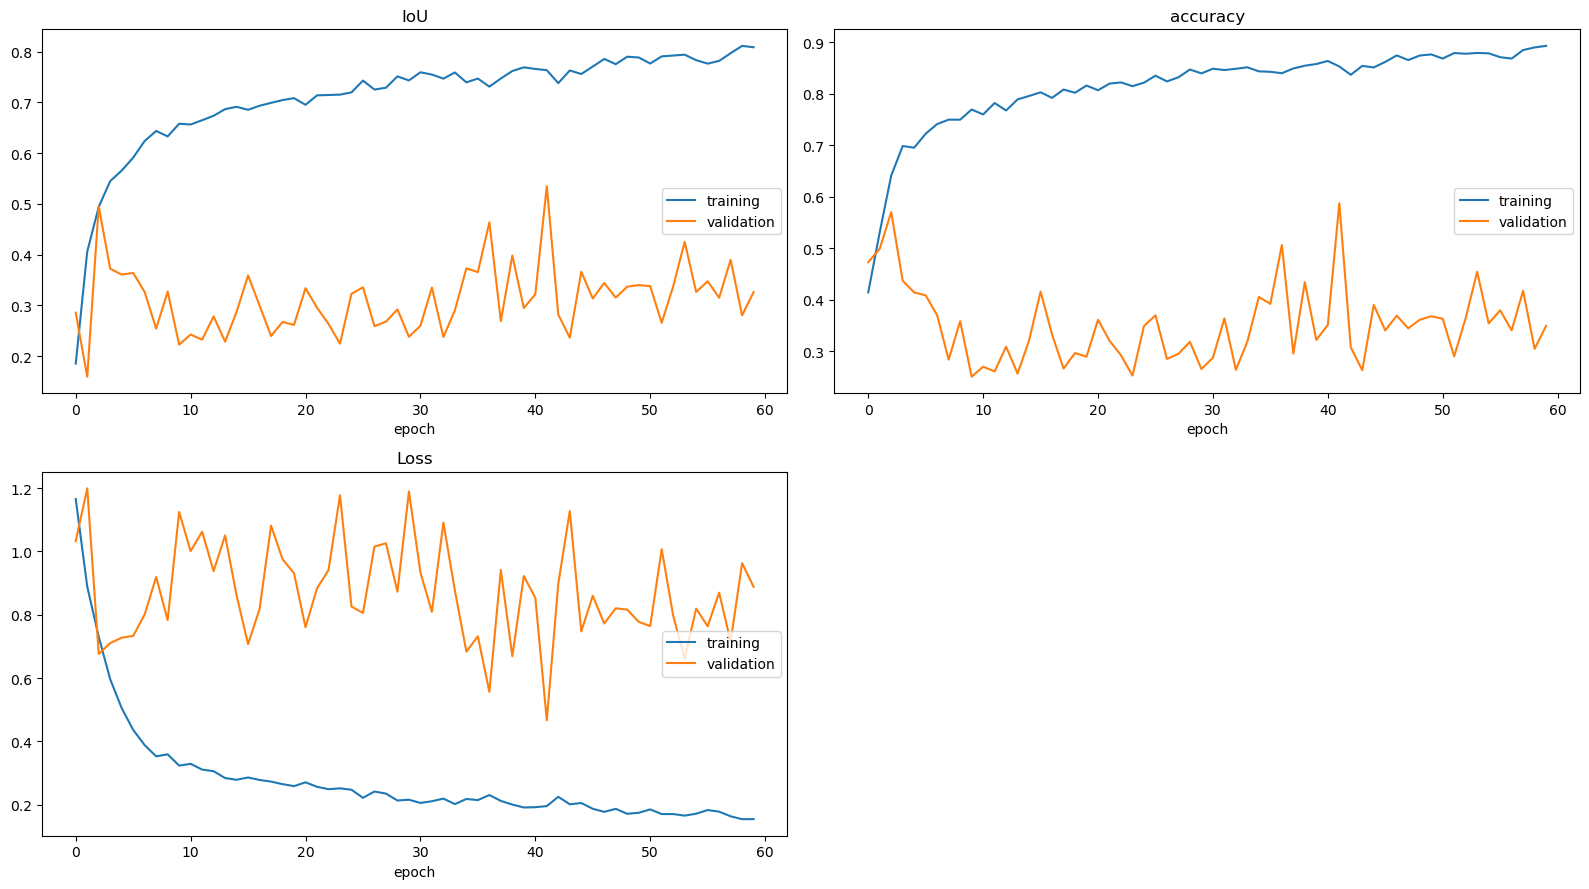

IoU
	training         	 (min:    0.185, max:    0.811, cur:    0.808)
	validation       	 (min:    0.160, max:    0.535, cur:    0.326)
accuracy
	training         	 (min:    0.414, max:    0.893, cur:    0.893)
	validation       	 (min:    0.251, max:    0.587, cur:    0.350)
Loss
	training         	 (min:    0.154, max:    1.165, cur:    0.155)
	validation       	 (min:    0.467, max:    1.199, cur:    0.888)


In [205]:
main(
   model = model,
   optimizer = optimizer,
   ckpt_dir = CKPT_DIR,
   device  = DEVICE,
   pin_memory = GPU_AVAILABLE
)


In [204]:
### train_img2d_dir = "BraTS2023_Preprocessed/input_data_128/train/images2D"
train_img3d_dir = "BraTS2023_Preprocessed/input_data_128/train/images3D"
train_mask_dir = "BraTS2023_Preprocessed/input_data_128/train/masks"
train_img2d_dir = "BraTS2023_Preprocessed/input_data_128/train/images2D"
 
val_img2d_dir = "BraTS2023_Preprocessed/input_data_128/val/images2D"
val_img3d_dir = "BraTS2023_Preprocessed/input_data_128/val/images3D"
val_mask_dir = "BraTS2023_Preprocessed/input_data_128/val/masks"


test_img3d_dir = "BraTS2023_Preprocessed/input_data_128/test/images3D"
test_img2d_dir = "BraTS2023_Preprocessed/input_data_128/test/images2D"
test_mask_dir = "BraTS2023_Preprocessed/input_data_128/test/masks"


val_img2d_list = os.listdir(val_img2d_dir)
val_img3d_list = os.listdir(val_img3d_dir)
val_mask_list = os.listdir(val_mask_dir)
 
# Initialize datasets with normalization only
train_dataset = BratsDataset(train_img3d_dir, train_img2d_dir, train_mask_dir, normalization=True)

val_dataset = BratsDataset(val_img3d_dir, val_img2d_dir, val_mask_dir, normalization=True)

test_dataset = BratsDataset(test_img3d_dir, test_img2d_dir, test_mask_dir)

# Print dataset statistics
print("Total Training Samples: ", len(train_dataset))
print("Total Val Samples: ", len(val_dataset))
print("Total test samples: ", len(test_dataset))
#Total Training Samples:  431
#Total Val Samples:  144

train_loader = DataLoader(train_dataset, batch_size = 5, shuffle = True, num_workers = 0)
val_loader = DataLoader(val_dataset, batch_size = 5, shuffle = False, num_workers = 0)
test_loader = DataLoader(test_dataset, batch_size = 1, shuffle = False, num_workers = 0)


Total Training Samples:  361
Total Val Samples:  77
Total test samples:  78


In [206]:
DEVICE, GPU_AVAILABLE = get_default_device()
trained_model = Fusionnet(channel_in=3, channel_out=4)
trained_model.load_state_dict(torch.load("model_checkpoint/3D_UNet_Brats2023/version_49/ckpt.tar", map_location = "cpu")['model'])
trained_model.to(DEVICE)
trained_model.eval()


Fusionnet(
  (decode1): Sequential(
    (0): Conv2d(256, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
  )
  (decode2): Sequential(
    (0): Conv2d(128, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
  )
  (decode3): Sequential(
    (0): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine

In [207]:
def test(
   model,
   loader,
   device,
   num_classes,
   epoch_idx,
   total_epochs
):
   model.eval()
 
 
   loss_record = MeanMetric()
   metric_record = MeanMetric()
   acc_record = MulticlassAccuracy(num_classes=num_classes, average='macro')
 
   loader_len = len(loader)
 
   with tqdm(total=loader_len, ncols=122) as tq:
       tq.set_description("Test")
 
       for image_3d, image_2d, target in loader:
           tq.update(1)
 
           image_3d = image_3d.to(device)
           image_2d = image_2d.to(device)
           target = target.to(device)

           with torch.no_grad():
               output_dict = model(image_3d, image_2d)
               
          
               
 
           clsfy_out = output_dict
           target = target.argmax(dim=1)  # Convert one-hot to class indices
 
           loss = combined_loss(clsfy_out, target)
           pred_idx = clsfy_out.argmax(dim=1)
 
           tp, fp, fn, tn = smp.metrics.get_stats(pred_idx, target, mode='multiclass', num_classes=num_classes)
           
           # Macro IoU
           metric_macro = smp.metrics.iou_score(tp, fp, fn, tn, reduction='macro')
 
           acc_record.update(pred_idx.cpu(), target.cpu())
           loss_record.update(loss.cpu(), weight=image_3d.shape[0])
           metric_record.update(metric_macro.cpu(), weight=image_3d.shape[0]) #data.shape = batch
 
       valid_epoch_loss = loss_record.compute()
       valid_epoch_metric = metric_record.compute()
       valid_epoch_acc = acc_record.compute()
 
   return valid_epoch_loss, valid_epoch_metric, valid_epoch_acc

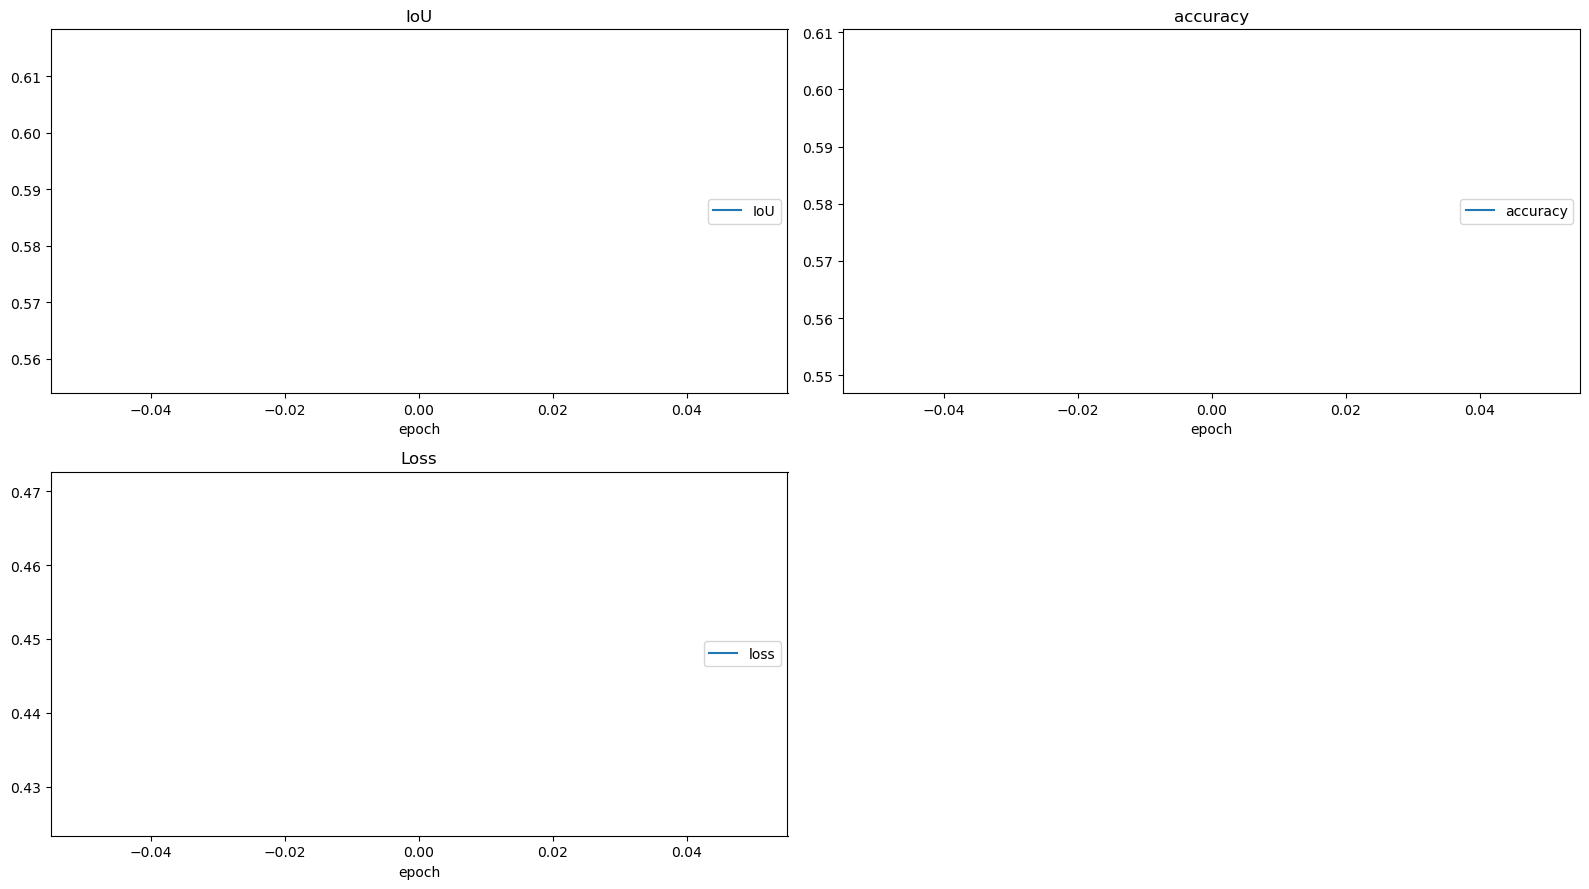

IoU
	IoU              	 (min:    0.586, max:    0.586, cur:    0.586)
accuracy
	accuracy         	 (min:    0.579, max:    0.579, cur:    0.579)
Loss
	loss             	 (min:    0.448, max:    0.448, cur:    0.448)


In [208]:
test_loss, test_metric, test_acc = test(
            model=trained_model,
            loader=test_loader,
            device="cpu",
            num_classes=4,
            epoch_idx=1,
            total_epochs=1,
        )
live_plot = PlotLosses(outputs=[MatplotlibPlot(cell_size=(8, 3)), ExtremaPrinter()])
        # Update live plot
live_plot.update(
    {
        "loss": test_loss,
        "accuracy": test_acc,
        "IoU": test_metric,
    }
    )
 
live_plot.send()
 